In [1]:
import pandas as pd


# Load the restaurant inspection results dataset
restaurant_inspection_df = pd.read_csv("restaurant_inspection.csv")

# Clean the column names by stripping any extra spaces
restaurant_inspection_df.columns = restaurant_inspection_df.columns.str.strip()

# Check the first few rows of both datasets to verify
restaurant_inspection_bk = restaurant_inspection_df[restaurant_inspection_df['BORO'] == 'Brooklyn']
restaurant_inspection_bk.head()
restaurant_inspection_bk['GRADE'].value_counts()





GRADE
A    24522
B     4386
C     2803
N     2081
Z     1323
P      278
Name: count, dtype: int64

In [2]:
restaurant_inspection_bk.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location Point1
0,50158120,KINJO,Brooklyn,11,ADAMS STREET,11201.0,6097758927,NaN,01/01/1900,NaN,...,NaN,40.704109,-73.988455,302.0,33.0,2100.0,3329396.0,3.000180e+09,BK38,NaN
1,50163468,MEI JADE HOUSE RESTAURANT INC,Brooklyn,6524,11 AVENUE,11219.0,6467391818,NaN,01/01/1900,NaN,...,NaN,40.628447,-74.006135,310.0,43.0,21200.0,3142185.0,3.057510e+09,BK30,NaN
2,50164027,DARUCHINI RESTAURANT AND CAFE,Brooklyn,1063,LIBERTY AVENUE,11208.0,3472948032,NaN,01/01/1900,NaN,...,NaN,40.678271,-73.870076,305.0,37.0,119000.0,3093584.0,3.041710e+09,BK83,NaN
16,50156247,FLY PRIVATE SOCIAL,Brooklyn,240,DEKALB AVENUE,11205.0,9175658382,NaN,01/01/1900,NaN,...,NaN,40.689470,-73.969581,302.0,35.0,19700.0,3059137.0,3.021050e+09,BK69,NaN
25,50095116,GLATT FAMILY EXPRESS,Brooklyn,4305,18 AVENUE,11218.0,7189728085,Jewish/Kosher,04/28/2025,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,40.631167,-73.976244,314.0,40.0,48000.0,3127649.0,3.054150e+09,BK42,NaN


In [3]:
restaurant_inspection_bk_zips_grades = restaurant_inspection_bk[['ZIPCODE', 'GRADE']]

In [4]:
restaurant_inspection_bk_zips_grades['GRADE'].value_counts()

GRADE
A    24522
B     4386
C     2803
N     2081
Z     1323
P      278
Name: count, dtype: int64

In [5]:
restaurant_inspection_bk_zips_grades['GRADE'].fillna('N', inplace=True)

# Verify the change
restaurant_inspection_bk_zips_grades.head()

# sum of all occurances of each zip

# total Cs in that zip 

#proportion columns = C/ all restaurants in zip


/var/folders/xv/zb6mjv_93435jvb4s_wsh3xm0000gn/T/ipykernel_87795/626022816.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  restaurant_inspection_bk_zips_grades['GRADE'].fillna('N', inplace=True)
/var/folders/xv/zb6mjv_93435jvb4s_wsh3xm0000gn/T/ipykernel_87795/626022816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurant_inspecti

,ZIPCODE,GRADE
0,11201.0,N
1,11219.0,N
2,11208.0,N
16,11205.0,N
25,11218.0,N


In [6]:
# Sum of all occurrences of each zip code
zip_counts = restaurant_inspection_bk_zips_grades['ZIPCODE'].value_counts().reset_index()
zip_counts.columns = ['ZIPCODE', 'total_restaurants']
print("Sum of all occurrences of each zip code:")
print(zip_counts.head())
print("\n")

# Total 'C' grades in each zip code
c_grade_counts = restaurant_inspection_bk_zips_grades[restaurant_inspection_bk_zips_grades['GRADE'] == 'C']['ZIPCODE'].value_counts().reset_index()
c_grade_counts.columns = ['ZIPCODE', 'total_C_grades']
print("Total 'C' grades in each zip code:")
print(c_grade_counts.head())
print("\n")

# Merge the counts to calculate the proportion
proportion_df = pd.merge(zip_counts, c_grade_counts, on='ZIPCODE', how='left')

# Fill NaN values in 'total_C_grades' (for zips with no 'C' grades) with 0
proportion_df['total_C_grades'] = proportion_df['total_C_grades'].fillna(0)

# Calculate the proportion of 'C' grades per zip code
proportion_df['proportion_C'] = proportion_df['total_C_grades'] / proportion_df['total_restaurants']

print("Proportion of 'C' grades per zip code:")
proportion_df.head()

Sum of all occurrences of each zip code:
   ZIPCODE  total_restaurants
0  11201.0               4715
1  11220.0               4466
2  11211.0               3985
3  11215.0               3577
4  11209.0               2915


Total 'C' grades in each zip code:
   ZIPCODE  total_C_grades
0  11201.0             198
1  11220.0             171
2  11237.0             127
3  11204.0             125
4  11215.0             120


Proportion of 'C' grades per zip code:


,ZIPCODE,total_restaurants,total_C_grades,proportion_C
0,11201.0,4715,198.0,0.041994
1,11220.0,4466,171.0,0.038289
2,11211.0,3985,118.0,0.029611
3,11215.0,3577,120.0,0.033548
4,11209.0,2915,84.0,0.028816


In [ ]:
%store -r final_df

# get income data dataframe from other nb 
print("The variable 'final_df' has been retrieved.")
income_df = final_df
final_df.head()

The variable 'final_df' has been retrieved.


,ZIP,Estimate Households Total,Income Above $110k (%),Income $80k-$110k (%),Income $40k-$80k (%),Income Below $40k (%),Income Above $110k (count),Income $80k-$110k (count),Income $40k-$80k (count),Income Below $40k (count)
0,11201,65368,53.9,19.9,11.4,14.9,35208,12977,7450,9734
1,11203,59560,16.4,29.1,27.3,27.2,9770,17333,16282,16177
2,11204,50424,15.2,29.6,28.3,26.9,7665,14903,14294,13563
3,11205,34133,30.5,22.2,21.6,25.7,10418,7581,7384,8766
4,11206,66394,16.7,23.5,22.2,37.7,11065,15572,14713,25045


In [8]:
# merge

income_df 
proportion_df.rename(columns={'ZIPCODE': 'ZIP'}, inplace=True)
proportion_df['ZIP'] = proportion_df['ZIP'].astype(int)

proportion_df.head()


,ZIP,total_restaurants,total_C_grades,proportion_C
0,11201,4715,198.0,0.041994
1,11220,4466,171.0,0.038289
2,11211,3985,118.0,0.029611
3,11215,3577,120.0,0.033548
4,11209,2915,84.0,0.028816


In [9]:
merged_df = pd.merge(proportion_df, income_df, on='ZIP', how='inner')
merged_df.head()


,ZIP,total_restaurants,total_C_grades,proportion_C,Estimate Households Total,Income Above $110k (%),Income $80k-$110k (%),Income $40k-$80k (%),Income Below $40k (%),Income Above $110k (count),Income $80k-$110k (count),Income $40k-$80k (count),Income Below $40k (count)
0,11201,4715,198.0,0.041994,65368,53.9,19.9,11.4,14.9,35208,12977,7450,9734
1,11220,4466,171.0,0.038289,56243,14.9,27.6,29.3,28.2,8356,15521,16505,15888
2,11211,3985,118.0,0.029611,54319,37.2,21.3,17.8,23.6,20191,11593,9671,12836
3,11215,3577,120.0,0.033548,59212,57.3,22.2,11.1,9.4,33901,13174,6572,5565
4,11209,2915,84.0,0.028816,60555,26.8,32.0,20.7,20.5,16231,19407,12505,12412


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use new income bracket columns
features = merged_df[[
    "proportion_C",
    "Income Below $40k (%)",
    "Income $40k-$80k (%)",
    "Income $80k-$110k (%)",
    "Income Above $110k (%)"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=0)
merged_df["cluster"] = kmeans.fit_predict(X_scaled)


In [11]:
merged_df.rename(columns={
    "Income Below $40k (%)": "pct_income_below_40k",
    "Income $40k-$80k (%)": "pct_income_40k_80k",
    "Income $80k-$110k (%)": "pct_income_80k_110k",
    "Income Above $110k (%)": "pct_income_above_110k"
}, inplace=True)

merged_df.head()


,ZIP,total_restaurants,total_C_grades,proportion_C,Estimate Households Total,pct_income_above_110k,pct_income_80k_110k,pct_income_40k_80k,pct_income_below_40k,Income Above $110k (count),Income $80k-$110k (count),Income $40k-$80k (count),Income Below $40k (count),cluster
0,11201,4715,198.0,0.041994,65368,53.9,19.9,11.4,14.9,35208,12977,7450,9734,3
1,11220,4466,171.0,0.038289,56243,14.9,27.6,29.3,28.2,8356,15521,16505,15888,1
2,11211,3985,118.0,0.029611,54319,37.2,21.3,17.8,23.6,20191,11593,9671,12836,3
3,11215,3577,120.0,0.033548,59212,57.3,22.2,11.1,9.4,33901,13174,6572,5565,3
4,11209,2915,84.0,0.028816,60555,26.8,32.0,20.7,20.5,16231,19407,12505,12412,1


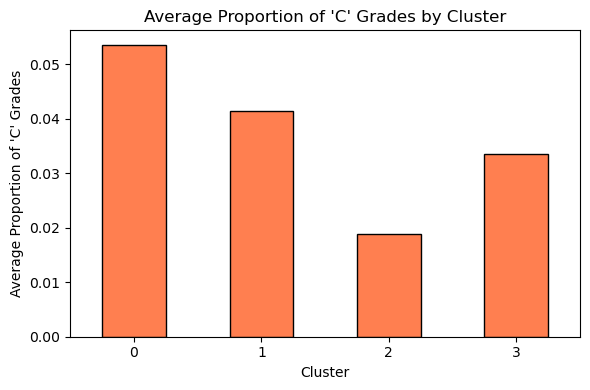

In [12]:
import matplotlib.pyplot as plt

income_bins = [
    "pct_income_below_40k",
    "pct_income_40k_80k",
    "pct_income_80k_110k",
    "pct_income_above_110k"
]


plt.figure(figsize=(6, 4))
merged_df.groupby("cluster")["proportion_C"].mean().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("Average Proportion of 'C' Grades by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Proportion of 'C' Grades")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


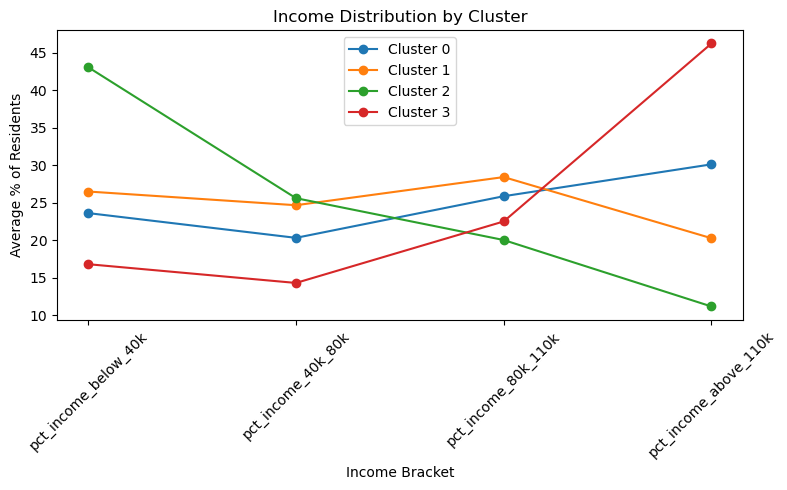

In [13]:
import matplotlib.pyplot as plt

income_bins = [
    "pct_income_below_40k",
    "pct_income_40k_80k",
    "pct_income_80k_110k",
    "pct_income_above_110k"
]

plt.figure(figsize=(8, 5))

for cluster_id, group in merged_df.groupby("cluster"):
    avg_income_distribution = group[income_bins].mean()
    plt.plot(income_bins, avg_income_distribution, marker='o', label=f"Cluster {cluster_id}")

plt.xticks(rotation=45)
plt.xlabel("Income Bracket")
plt.ylabel("Average % of Residents")
plt.title("Income Distribution by Cluster")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
merged_df

,ZIP,total_restaurants,total_C_grades,proportion_C,Estimate Households Total,pct_income_above_110k,pct_income_80k_110k,pct_income_40k_80k,pct_income_below_40k,Income Above $110k (count),Income $80k-$110k (count),Income $40k-$80k (count),Income Below $40k (count),cluster
0,11201,4715,198.0,0.041994,65368,53.9,19.9,11.4,14.9,35208,12977,7450,9734,3
1,11220,4466,171.0,0.038289,56243,14.9,27.6,29.3,28.2,8356,15521,16505,15888,1
2,11211,3985,118.0,0.029611,54319,37.2,21.3,17.8,23.6,20191,11593,9671,12836,3
3,11215,3577,120.0,0.033548,59212,57.3,22.2,11.1,9.4,33901,13174,6572,5565,3
4,11209,2915,84.0,0.028816,60555,26.8,32.0,20.7,20.5,16231,19407,12505,12412,1
5,11217,2611,87.0,0.033321,38455,51.0,19.4,12.8,16.7,19614,7478,4905,6420,3
6,11226,2573,111.0,0.043140,77763,21.0,31.1,25.7,22.3,16339,24188,19982,17371,1
7,11237,2562,127.0,0.049571,35236,20.7,32.3,23.5,23.7,7278,11382,8280,8350,1
8,11214,2486,91.0,0.036605,62372,17.8,25.1,28.6,28.4,11130,15685,17841,17686,1
9,11238,2438,77.0,0.031583,53863,43.3,26.1,14.2,16.4,23333,14050,7650,8829,3
